### Visualisierung 1

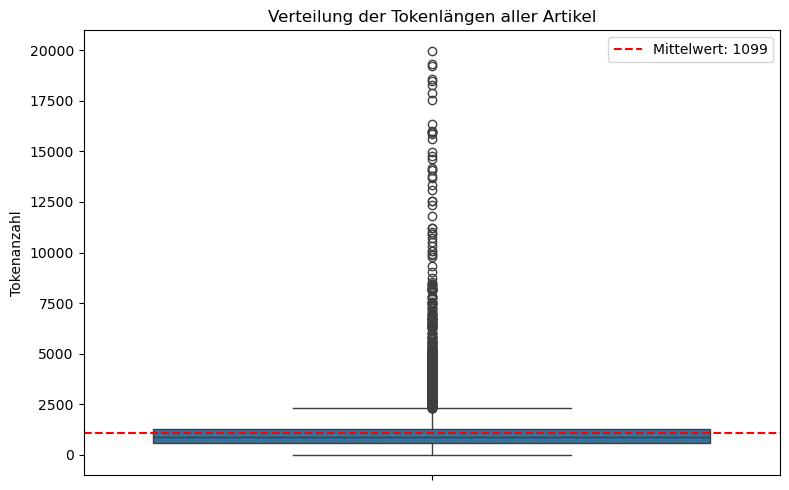

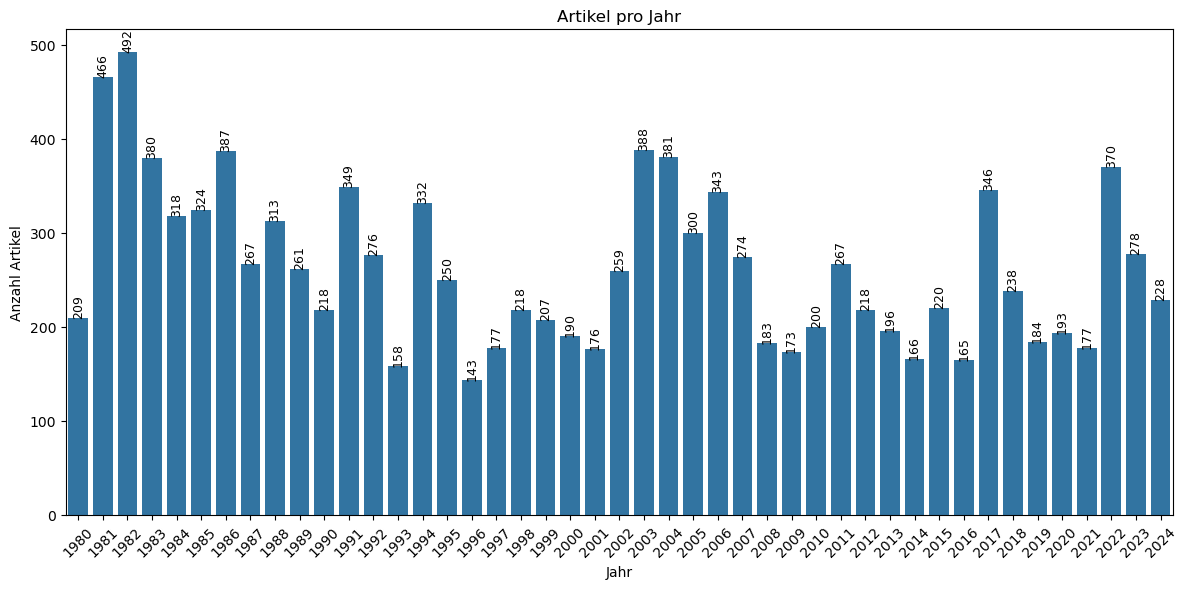

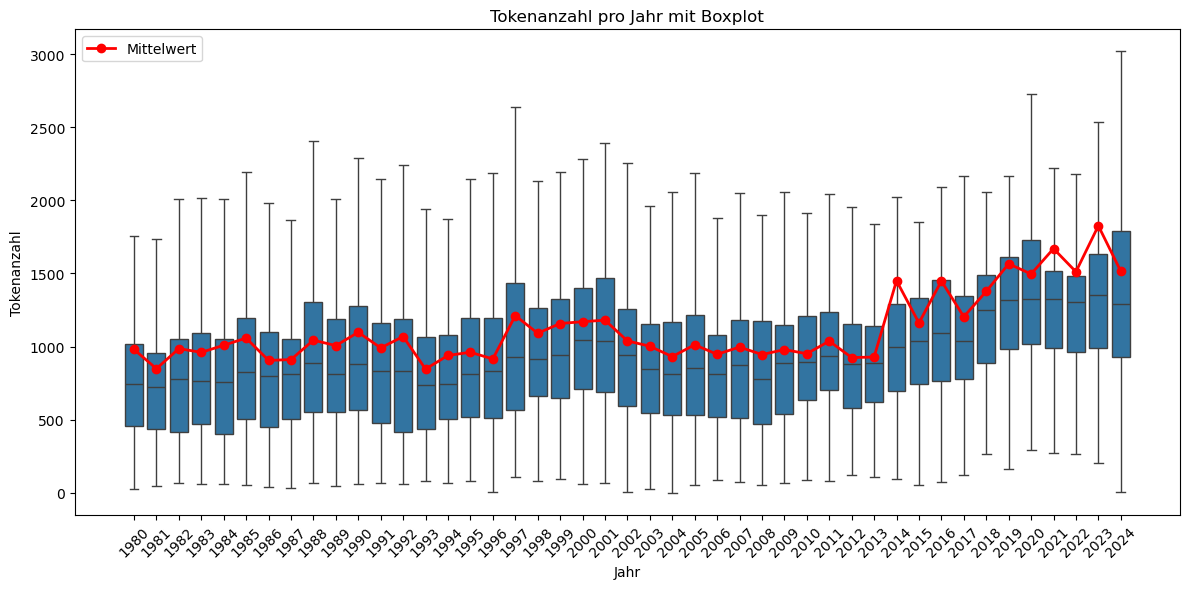

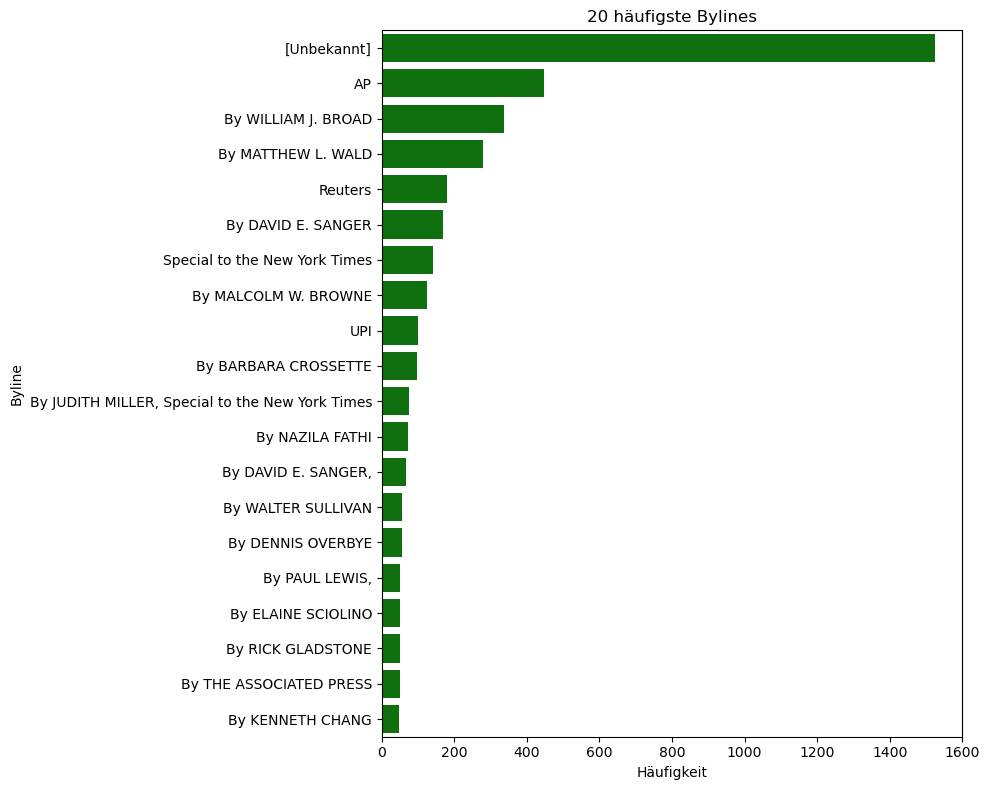

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

def visu1_csv(csv_pfad):
    df = pd.read_csv(csv_pfad, sep = ";", encoding = "utf-8", quotechar= '"')

    df["Jahr"] = pd.to_datetime(df["Datum_standardisiert"], errors = "coerce").dt.year

    def tokenisieren(text):
        if pd.isna(text):
            return 0
        return len(re.findall(r"\b\w+\b", text))

    df["Tokenanzahl"] = df["Text"].apply(tokenisieren)

# 1.: Boxplot Tokenanzahl
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, y="Tokenanzahl")
    plt.title("Verteilung der Tokenlängen aller Artikel") 
    plt.tight_layout()
    mean_val = df["Tokenanzahl"].mean()
    plt.axhline(y=mean_val, color="red", linestyle="--", label=f"Mittelwert: {mean_val:.0f}")
    plt.legend()
    plt.tight_layout()
    #plt.savefig("token_bxplt_gesamt.png", bbox_inches="tight", dpi=600) #uncomment when happy with result
    plt.show()
       
# Grafik 2: Artikel pro Jahr
    df_mit_jahr = df[df["Jahr"].notna()].copy()
    df_mit_jahr["Jahr"] = df_mit_jahr["Jahr"].astype(int)

    plt.figure(figsize=(12, 6))
    jahre_sortiert = sorted(df_mit_jahr["Jahr"].unique())
    ax = sns.countplot(data=df_mit_jahr, x="Jahr", order=jahre_sortiert)
    plt.title("Artikel pro Jahr")
    plt.xlabel("Jahr")
    plt.ylabel("Anzahl Artikel")
    plt.xticks(rotation=45)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9,
                rotation=90)
    plt.tight_layout()
    # plt.savefig("nr_artikel_pro_jahr_.png", bbox_inches="tight", dpi=600)
    plt.show()

    # Grafik 3: Tokenanzahl nach Jahr  
    plt.figure(figsize=(12, 6))
    df_mit_jahr["Jahr_sortiert"] = df_mit_jahr["Jahr"]
    jahre_sortiert = sorted(df_mit_jahr["Jahr"].unique())
    sns.boxplot(data=df_mit_jahr, x="Jahr", y="Tokenanzahl", order=jahre_sortiert, showfliers=False)
    plt.title("Tokenanzahl pro Jahr mit Boxplot")
    yearly_means = df_mit_jahr.groupby("Jahr")["Tokenanzahl"].mean()
    plt.plot(range(len(jahre_sortiert)), [yearly_means[j] for j in jahre_sortiert], 
             color="red", marker="o", linewidth=2, markersize=6, label="Mittelwert")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    #plt.savefig("token_pro_jahr.png", bbox_inches="tight", dpi=600)
    plt.show()
  
# 4. 20 häufigste Bylines 
    plt.figure(figsize=(10, 8))
    df["Byline"] = df["Byline"].fillna("[Unbekannt]")
    top_bylines = df["Byline"].value_counts().nlargest(20)
    sns.barplot(y=top_bylines.index, x=top_bylines.values, color="green")
    plt.title("20 häufigste Bylines")
    plt.xlabel("Häufigkeit")
    plt.tight_layout()
    #plt.savefig("top_bylines.png", bbox_inches="tight", dpi=600) #uwhwr
    plt.show()

visu1_csv("artikel_korpus_fin.csv")

### Visualisierung 2

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/lennertbusse/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
100%|████████████████████████████████████| 11509/11509 [00:35<00:00, 321.41it/s]


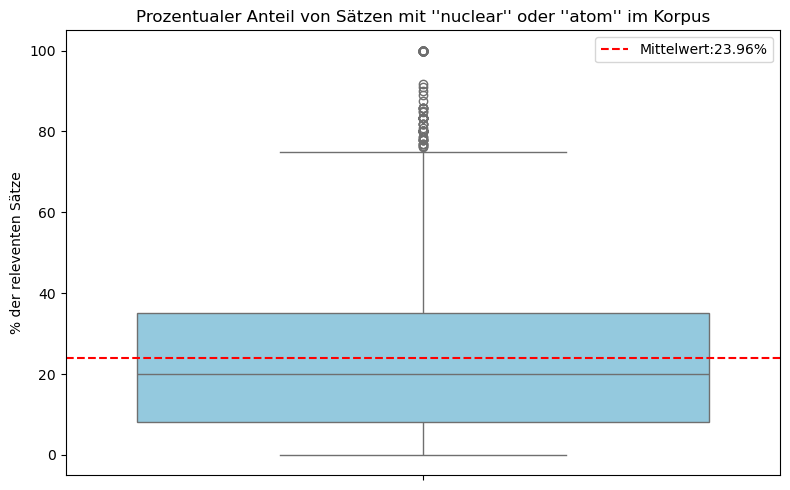

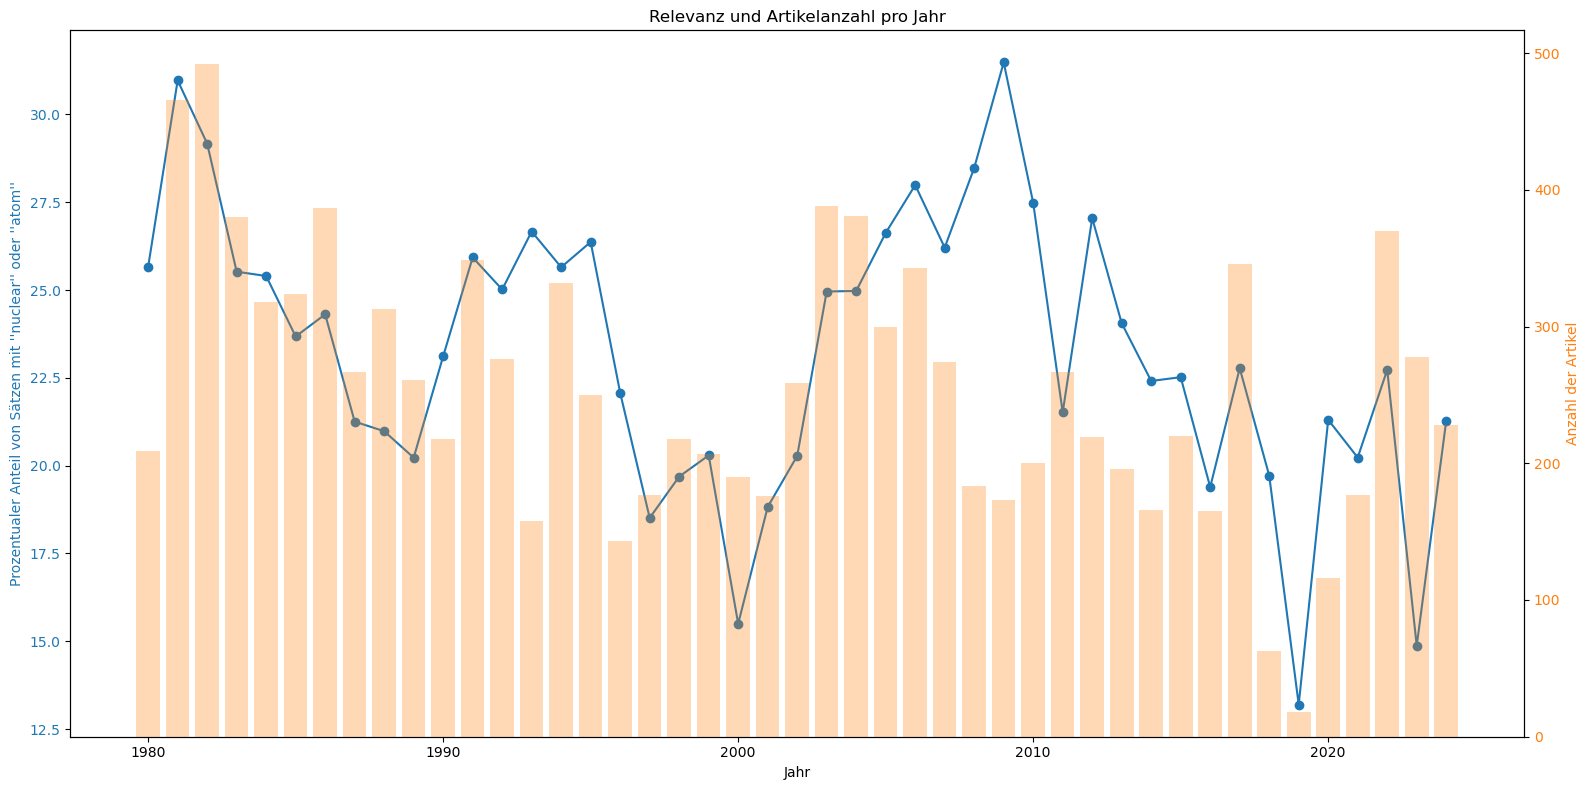

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import sent_tokenize
from tqdm import tqdm
tqdm.pandas()
nltk.download("punkt")

def visu2_csv(csv_pfad):
    df = pd.read_csv(csv_pfad, sep=";", encoding="utf-8", quotechar='"')
    df["Jahr"] = pd.to_datetime(df["Datum_standardisiert"], errors="coerce").dt.year
    
    def atom_nuclear_ratio(text): 
        if pd.isna(text):
            return 0, 0
        saetze = sent_tokenize(text.strip())
        gesamt = len([s for s in saetze if s.strip() !=""])
        if gesamt == 0:
            return 0,0
        pattern = re.compile(r"\b(atom\w*|nuclear\w*)\b", re.IGNORECASE)
        relevant = [s for s in saetze if pattern.search(s)]
        return len(relevant) / gesamt * 100, gesamt 

    df[["Prozent_atom_nuclear", "Satzanzahl"]] = df["Text"].progress_apply(lambda x: pd.Series(atom_nuclear_ratio(x)))

# 5. Prozentuale Relevanz als Boxplot
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df["Prozent_atom_nuclear"], color="skyblue")
    mean_val = df["Prozent_atom_nuclear"].mean()
    plt.axhline(y=mean_val, color="red", linestyle="--", label=f"Mittelwert:{mean_val:.2f}%")
    plt.ylabel("% der releventen Sätze")
    plt.title("Prozentualer Anteil von Sätzen mit ''nuclear'' oder ''atom'' im Korpus")
    plt.legend()
    plt.tight_layout()
    plt.savefig("2mean_relevance.png", bbox_inches="tight", dpi=600) #uwhwr
    plt.show()

# 6. Prozentuale Relevant pro Jahr & # 7. Absolute Relevanz pro Jahr 
    jahr_df = df.groupby("Jahr").agg({"Prozent_atom_nuclear": "mean", "ID": "count"}).dropna()
    jahr_df.rename(columns={"ID": "Artikelanzahl"}, inplace=True)
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # 6
    ax1.set_xlabel("Jahr")
    ax1.set_ylabel("Prozentualer Anteil von Sätzen mit ''nuclear'' oder ''atom''", color="tab:blue")
    ax1.plot(jahr_df.index, jahr_df["Prozent_atom_nuclear"], color="tab:blue", marker="o", label="Ø Relevanz")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # 7 
    ax2 = ax1.twinx()
    ax2.set_ylabel("Anzahl der Artikel", color="tab:orange")
    ax2.bar(jahr_df.index, jahr_df["Artikelanzahl"], alpha=0.3, color="tab:orange", label="Anzahl Artikel")
    ax2.tick_params(axis='y', labelcolor="tab:orange")

    plt.title("Relevanz und Artikelanzahl pro Jahr")
    fig.tight_layout()
    plt.savefig("2relevance_pro_jahr_total.png", bbox_inches="tight", dpi=900) #uwhwr
    plt.show()

    return df[["ID", "Jahr", "Prozent_atom_nuclear", "Satzanzahl"]]

df_analyse = visu2_csv("artikel_korpus_fin.csv")

### Visualisierung 3

Bearbeite Kategorie: Subject


/var/folders/m3/tbfwmsfs7wn1h20r_q9tlljr0000gn/T/ipykernel_2691/1091330147.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[v for k, v in top20], y=[k for k, v in top20], palette="ocean")


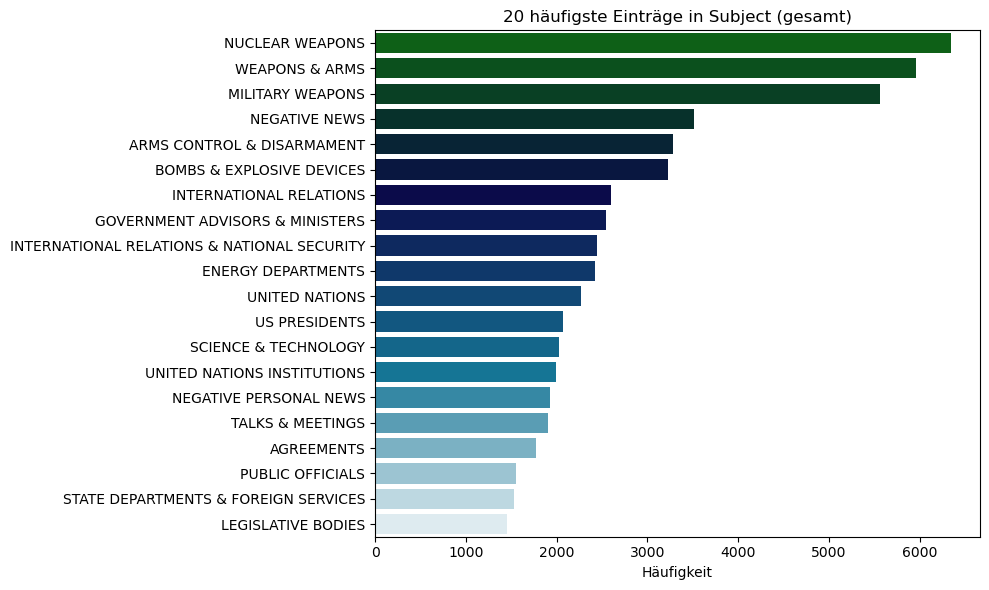

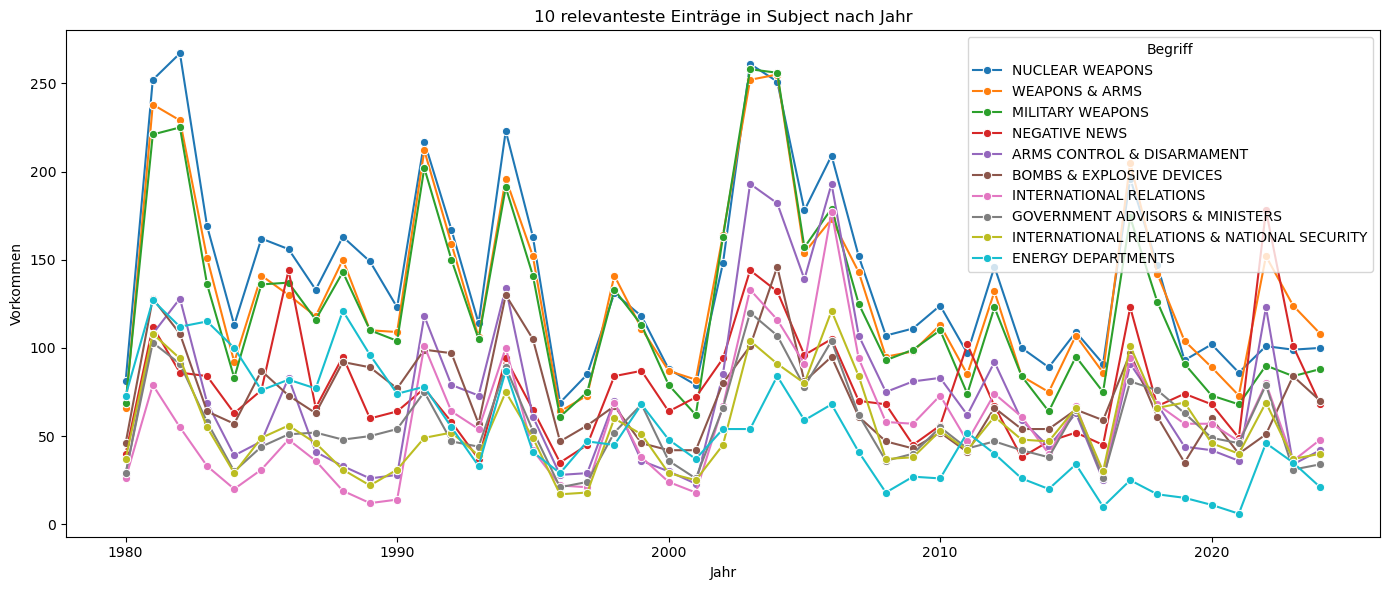

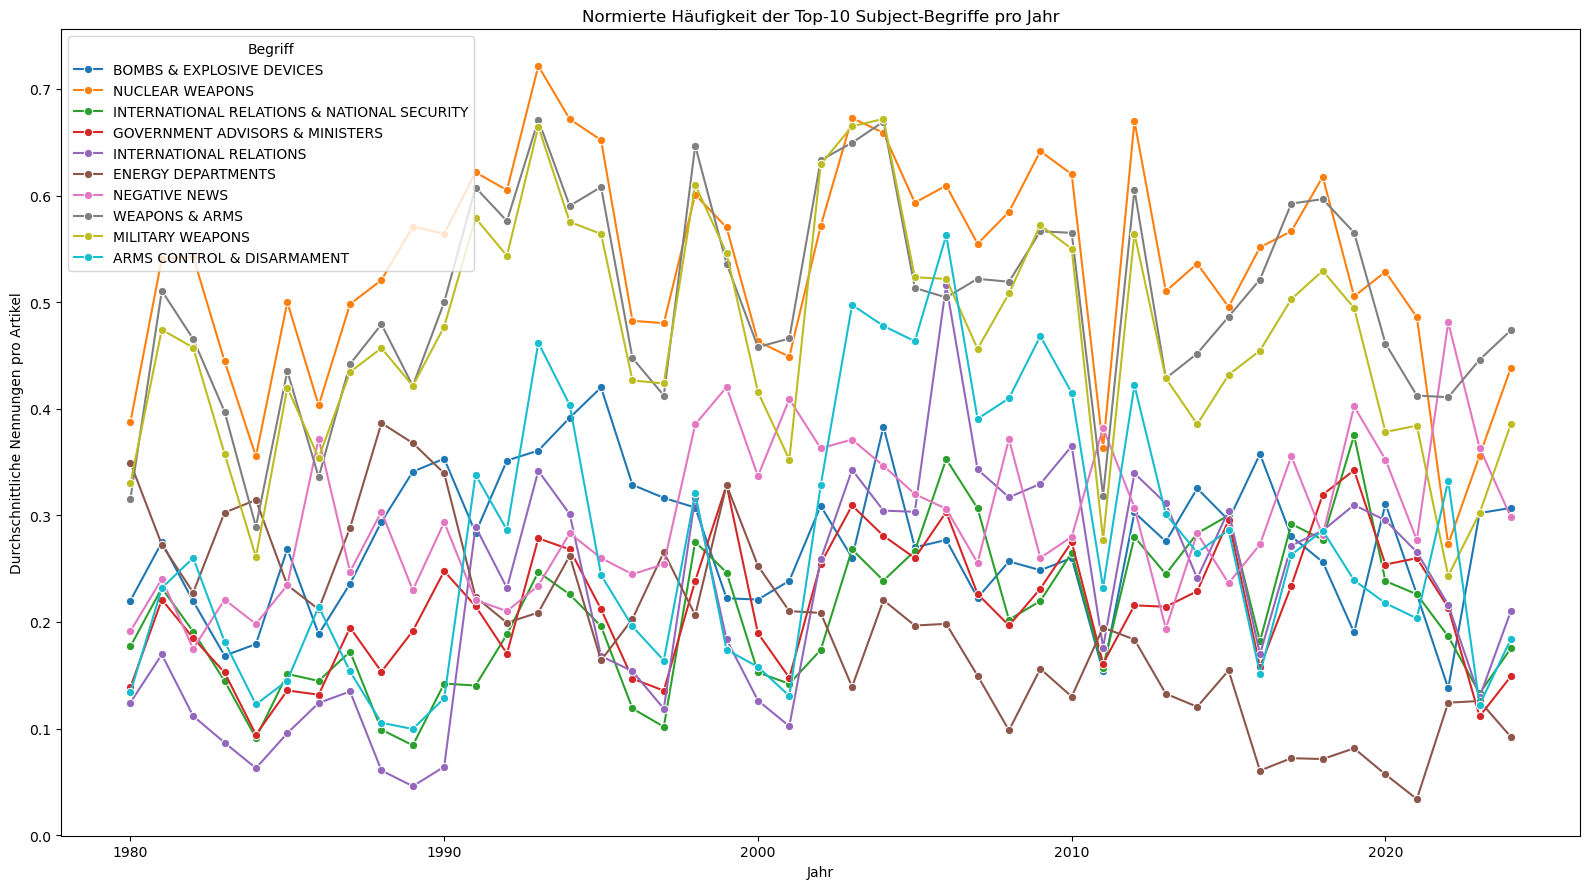

Bearbeite Kategorie: Industry


/var/folders/m3/tbfwmsfs7wn1h20r_q9tlljr0000gn/T/ipykernel_2691/1091330147.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[v for k, v in top20], y=[k for k, v in top20], palette="ocean")


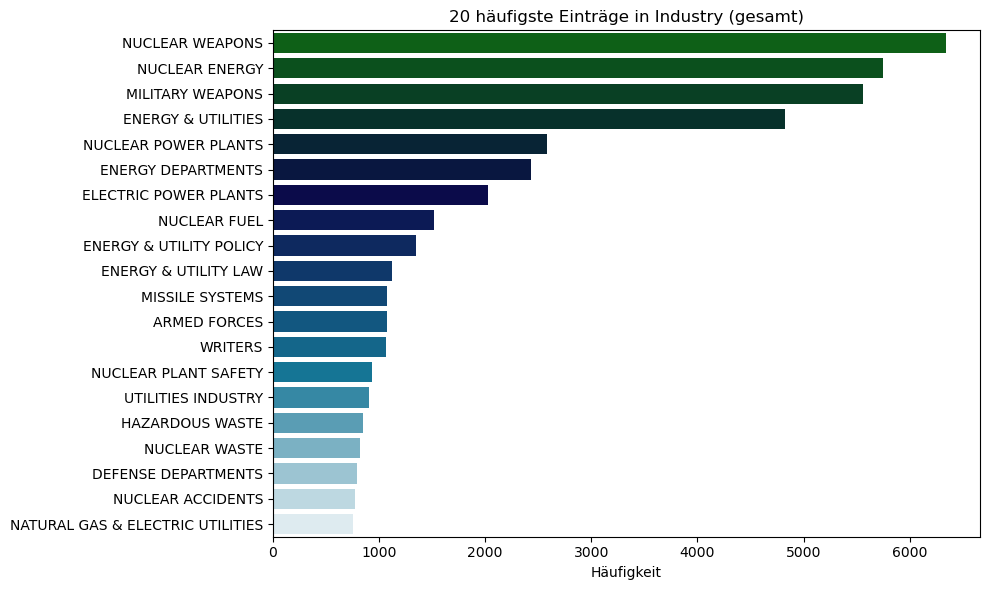

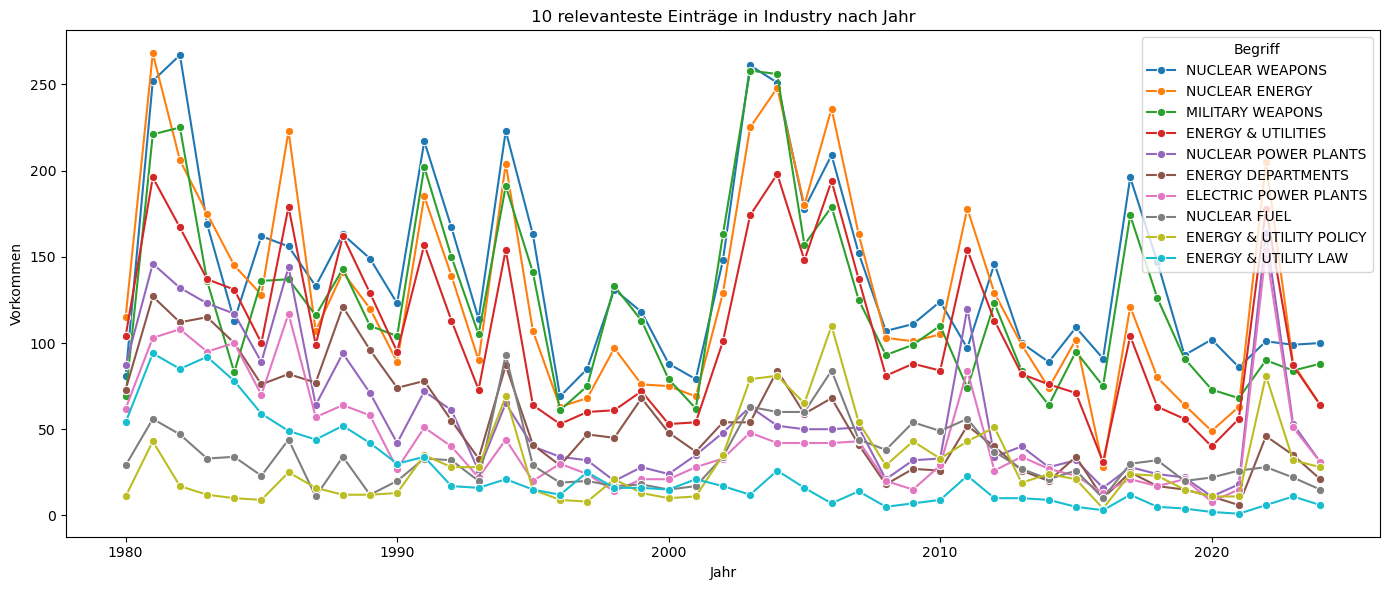

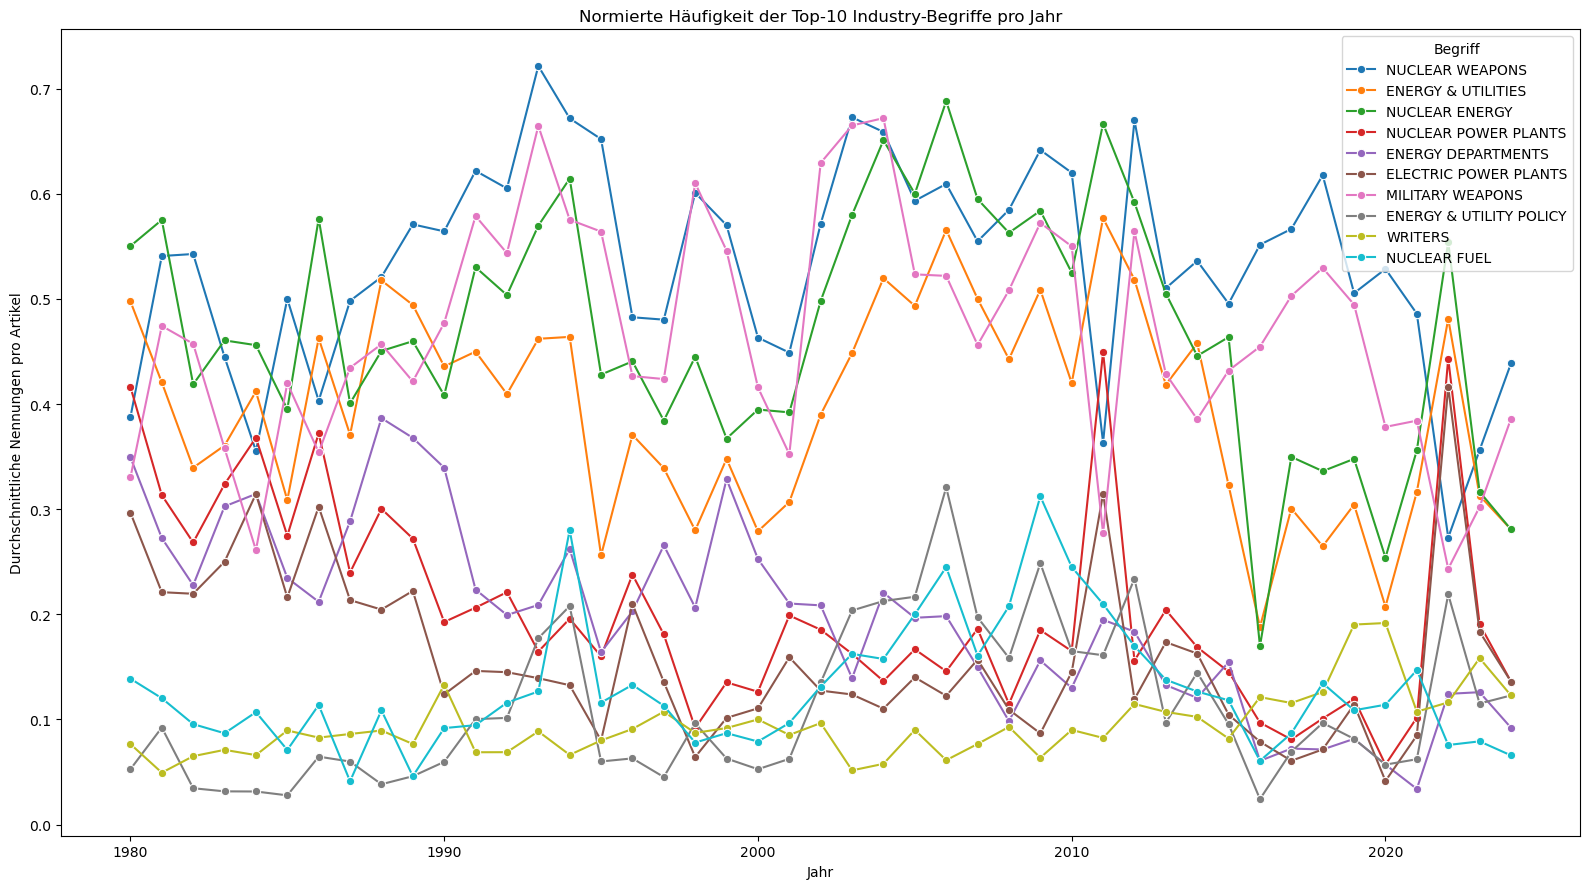

Bearbeite Kategorie: Person


/var/folders/m3/tbfwmsfs7wn1h20r_q9tlljr0000gn/T/ipykernel_2691/1091330147.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[v for k, v in top20], y=[k for k, v in top20], palette="ocean")


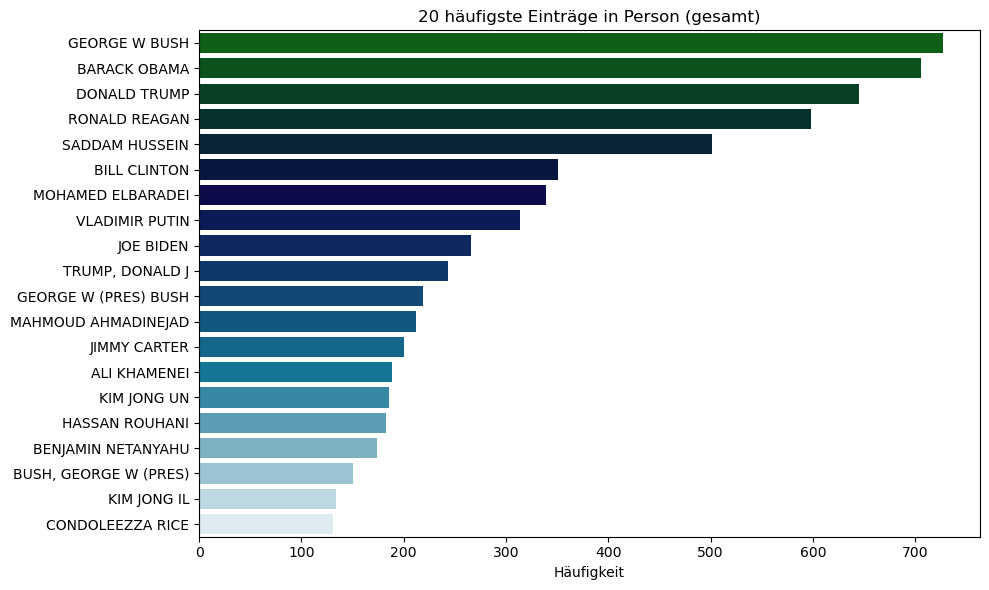

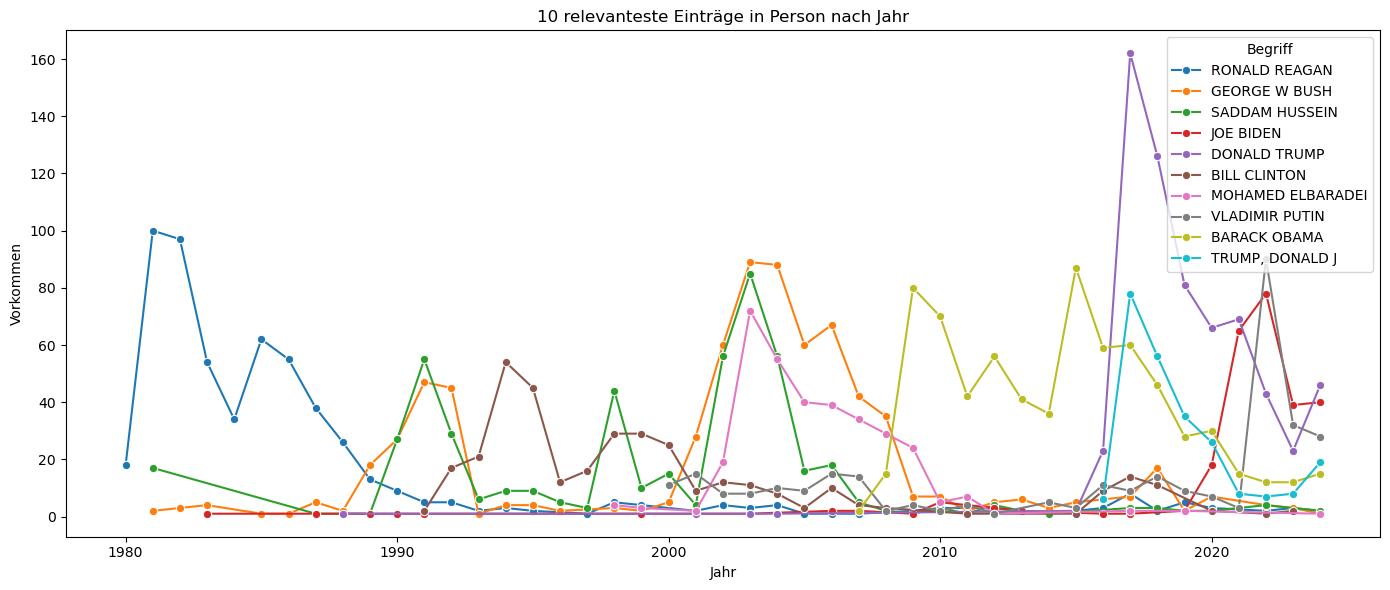

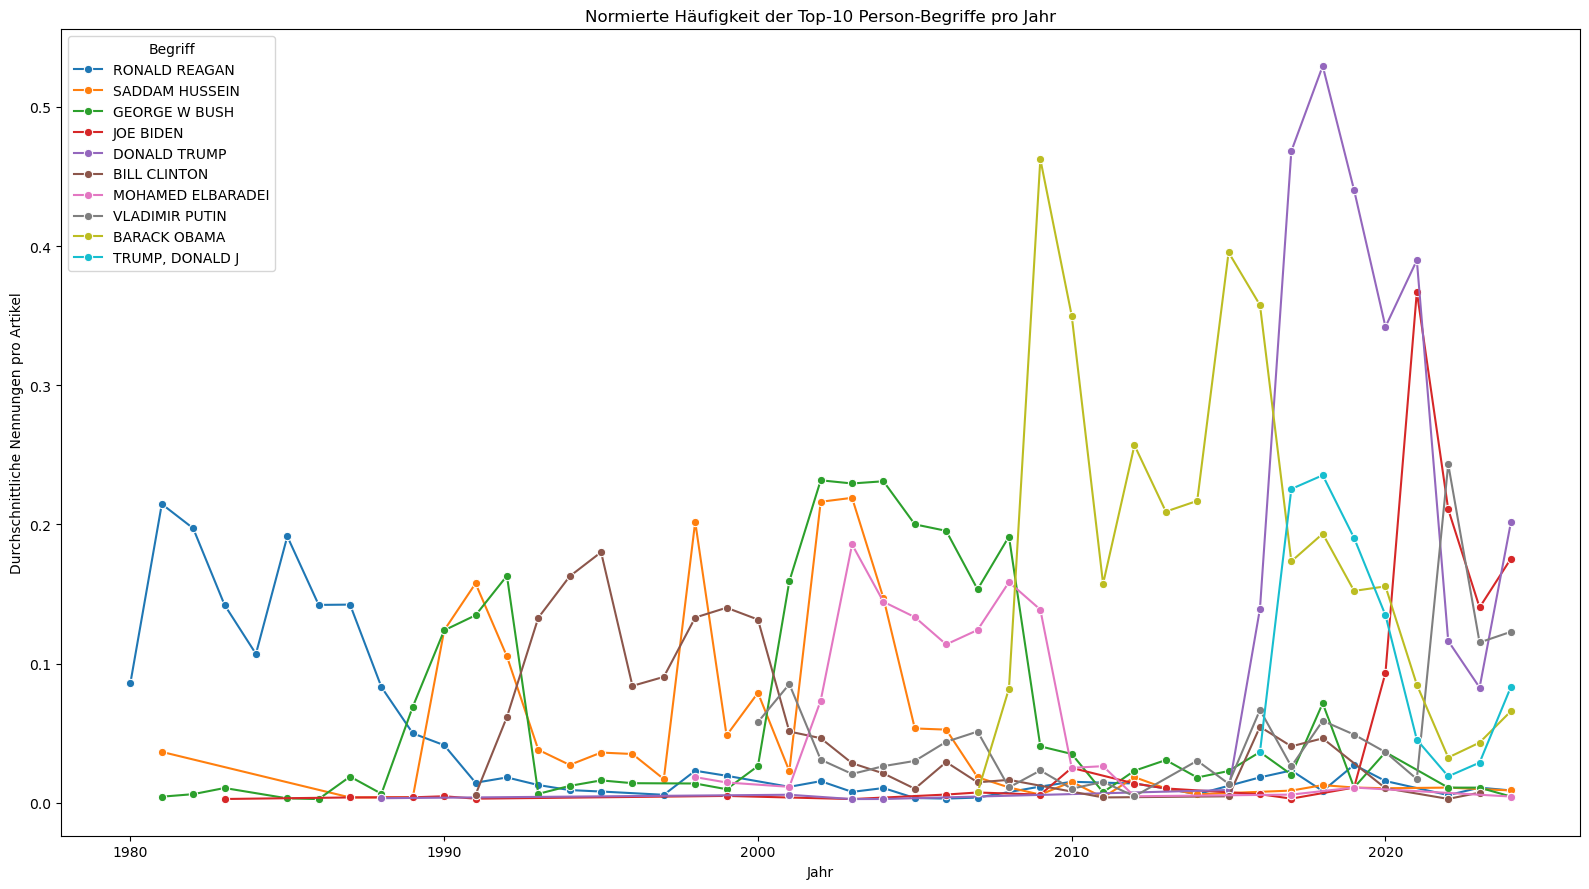

Bearbeite Kategorie: Geographic


/var/folders/m3/tbfwmsfs7wn1h20r_q9tlljr0000gn/T/ipykernel_2691/1091330147.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[v for k, v in top20], y=[k for k, v in top20], palette="ocean")


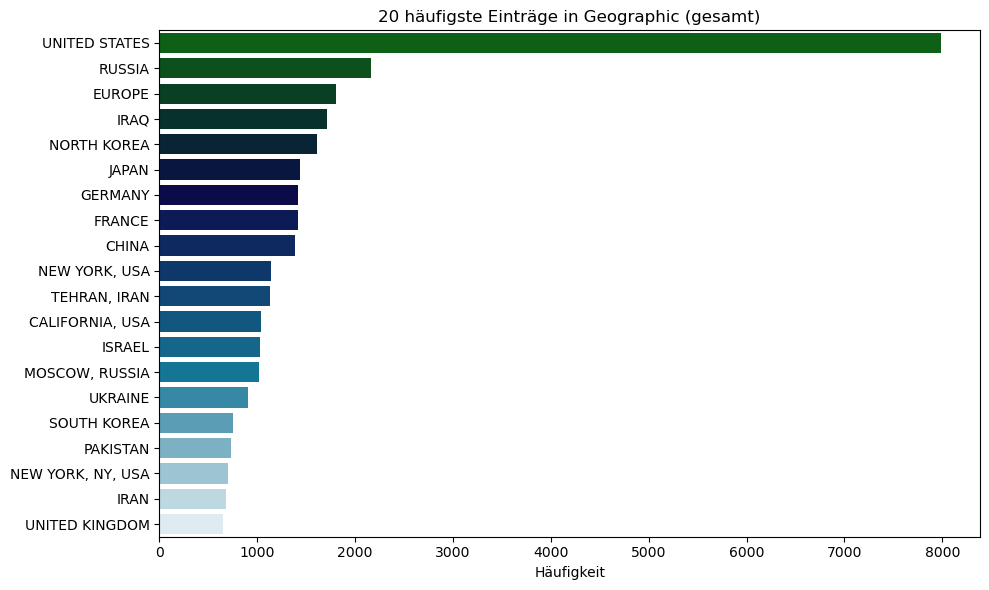

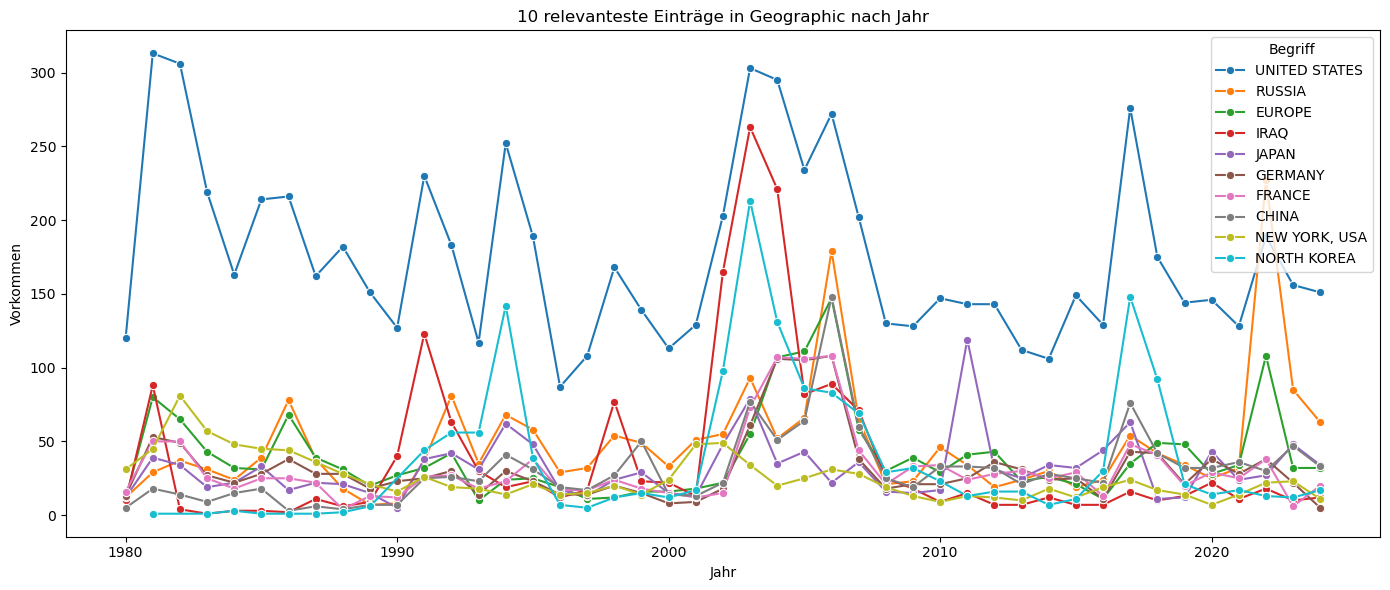

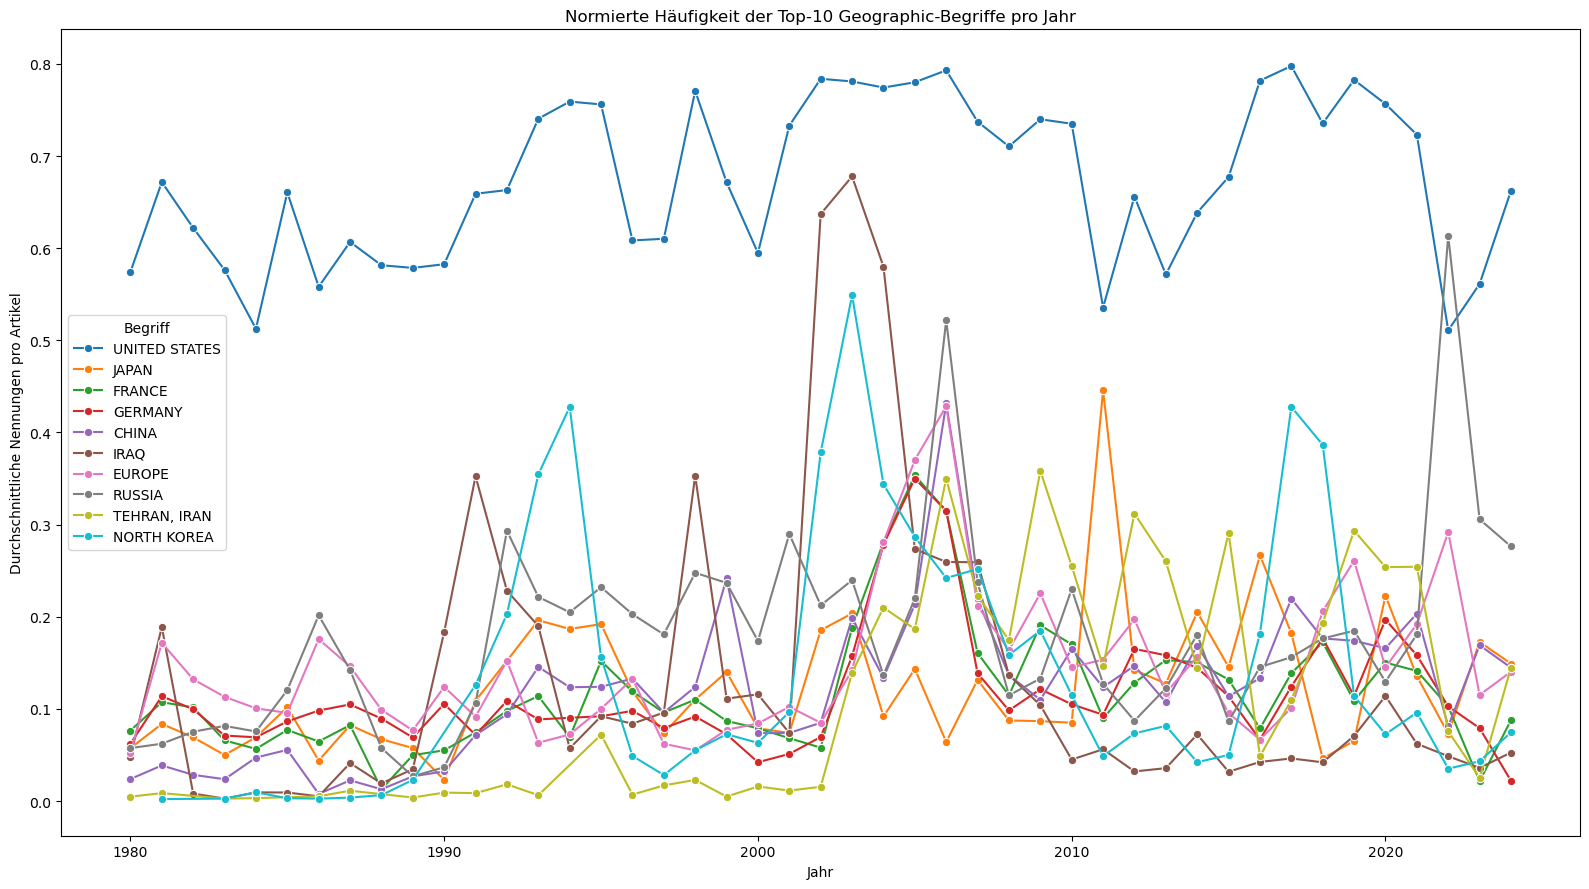

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

def clean_list_field(text):
    """Entfernt Prozentangaben und splittet semikolon-getrennte Werte"""
    if pd.isna(text):
        return []
    parts = text.split(";")
    cleaned = [re.sub(r"\s*\(\d+%\)", "", p).strip().upper() for p in parts if p.strip()]
    return cleaned

def visu3_csv(csv_pfad):
    df = pd.read_csv(csv_pfad, sep=";", encoding="utf-8", quotechar='"')
    df["Jahr"] = pd.to_datetime(df["Datum_standardisiert"], errors="coerce").dt.year

    kategorien = ["Subject", "Industry", "Person", "Geographic"]

    for kategorie in kategorien:
        print(f"Bearbeite Kategorie: {kategorie}")
        df[kategorie + "_cleaned"] = df[kategorie].apply(clean_list_field)

        # A. Gesamtstatistik (alle Artikel)
        all_terms = sum(df[kategorie + "_cleaned"].tolist(), [])
        counter = Counter(all_terms)
        top20 = counter.most_common(20)

        plt.figure(figsize=(10, 6))
        sns.barplot(x=[v for k, v in top20], y=[k for k, v in top20], palette="ocean")
        plt.title(f"20 häufigste Einträge in {kategorie} (gesamt)")
        plt.xlabel("Häufigkeit")
        plt.tight_layout()
        plt.savefig(f"3A{kategorie.lower()}_top20_alltime.png", bbox_inches="tight", dpi=600)
        plt.show()

        # B. Gesamtstatistik nach Jahr  
        jahr_counter = {}
        for jahr, gruppe in df.groupby("Jahr"):
            terms = sum(gruppe[kategorie + "_cleaned"].tolist(), [])
            jahr_counter[jahr] = Counter(terms)

        # Alle Top-Begriffe aus allen Jahren extrahieren
        all_jahr_terms = sum((list(c.keys()) for c in jahr_counter.values()), [])
        top_terms = [k for k, v in counter.most_common(10)]
        
        jahr_df = pd.DataFrame([
            {"Jahr": jahr, "Begriff": begriff, "Anzahl": count[begriff]}
            for jahr, count in jahr_counter.items()
            for begriff in top_terms if begriff in count
        ])

        plt.figure(figsize=(14, 6))
        sns.lineplot(data=jahr_df, x="Jahr", y="Anzahl", hue="Begriff", marker="o")
        plt.title(f"{len(top_terms)} relevanteste Einträge in {kategorie} nach Jahr")
        plt.ylabel("Vorkommen")
        plt.tight_layout()
        plt.savefig(f"3B{kategorie.lower()}_top10_relevance.png", bbox_inches="tight", dpi=900)
        plt.show()

    # D. Relative Häufigkeit pro Jahr (normiert durch Artikelanzahl)
        jahr_anzahl_artikel = df.groupby("Jahr").size()
        rel_data = []

        for jahr, gruppe in df.groupby("Jahr"):
            n_artikel = len(gruppe)
            if n_artikel == 0:
                continue
            alle_begriffe = sum(gruppe[kategorie + "_cleaned"].tolist(), [])
            counter = Counter(alle_begriffe)

            for begriff, anzahl in counter.items():
                rel_data.append({
                    "Jahr": jahr,
                    "Begriff": begriff,
                    "Normierte_Häufigkeit": anzahl / n_artikel
                })

        rel_df = pd.DataFrame(rel_data)

        # Nur Top-10 Begriffe (über alle Jahre) anzeigen
        top_terms_rel = rel_df.groupby("Begriff")["Normierte_Häufigkeit"].sum().nlargest(10).index
        rel_df = rel_df[rel_df["Begriff"].isin(top_terms_rel)]

        plt.figure(figsize=(16, 9))
        sns.lineplot(data=rel_df, x="Jahr", y="Normierte_Häufigkeit", hue="Begriff", marker="o")
        plt.title(f"Normierte Häufigkeit der Top-{len(top_terms_rel)} {kategorie}-Begriffe pro Jahr")
        plt.ylabel("Durchschnittliche Nennungen pro Artikel")
        plt.tight_layout()
        plt.savefig(f"3D{kategorie.lower()}_top10_normalisiert.png", bbox_inches="tight", dpi=900)
        plt.show()
        
visu3_csv("artikel_korpus_fin.csv")